In [11]:
# latest kglab v0.7.0 dropped SubgraphTensor
!pip3 install kglab==v0.7.0 pyvis matplotlib

  Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.0-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (113 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.0-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2

In [4]:
import kglab

kg = kglab.KnowledgeGraph()
kg.load_rdf("https://storage.googleapis.com/kglab-tutorial/foaf.rdf", format="xml")

measure = kglab.Measure()
measure.measure_graph(kg)

print("edges: {}\n".format(measure.get_edge_count()))
print("nodes: {}\n".format(measure.get_node_count()))

ttl = kg.save_rdf_text()
print(ttl)

edges: 62

nodes: 35

@prefix : <http://www.w3.org/2003/01/geo/wgs84_pos#> .
@prefix admin: <http://webns.net/mvcb/> .
@prefix cert: <http://www.w3.org/ns/auth/cert#> .
@prefix doap: <http://usefulinc.com/ns/doap#> .
@prefix foaf: <http://xmlns.com/foaf/0.1/> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix redfoot: <http://redfoot.net/2005/session#> .
@prefix rsa: <http://www.w3.org/ns/auth/rsa#> .

<https://storage.googleapis.com/kglab-tutorial/foaf.rdf> a foaf:PersonalProfileDocument ;
    admin:errorReportsTo <mailto:leigh@ldodds.com> ;
    admin:generatorAgent <http://www.ldodds.com/foaf/foaf-a-matic> ;
    foaf:maker <http://bigasterisk.com/foaf.rdf#drewp> ;
    foaf:primaryTopic <http://bigasterisk.com/foaf.rdf#drewp> .

<http://bblfish.net/people/henry/card#me> a foaf:Person ;
    rdfs:seeAlso <http://bblfish.net/people/henry/card> ;
    foaf:name "Henry Story" .

<http://collectivesource.com/foaf.rdf#nathan> a fo

In [30]:
VIS_STYLE = {
    "wtm": {
        "color": "orange",
        "size": 40,
    },
    "ind":{
        "color": "blue",
        "size": 30,
    },
}

import kglab_subg
subgraph = kglab_subg.SubgraphTensor(kg)
pyvis_graph = subgraph.build_pyvis_graph(notebook=True, style=VIS_STYLE)

In [31]:
pyvis_graph = subgraph.build_pyvis_graph(notebook=True, style=VIS_STYLE)
pyvis_graph.force_atlas_2based()
pyvis_graph.show("tmp.fig03.html", notebook=False)

tmp.fig03.html


In [2]:
from rdflib import Graph

g = Graph()
g.parse("http://www.w3.org/People/Berners-Lee/card")
#g.serialize(destination="tbl.ttl", format="turtle")

<Graph identifier=N71d44a9075514f839e0923ca1e9fa03b (<class 'rdflib.graph.Graph'>)>

In [4]:
from rdflib.extras.external_graph_libs import rdflib_to_networkx_multidigraph, rdflib_to_networkx_graph
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

#G = rdflib_to_networkx_multidigraph(g)
#f = plt.figure()
#f.set_figwidth(24)
#f.set_figheight(24) 
# Plot Networkx instance of RDF Graph
#pos = nx.spring_layout(G, scale=2)
#edge_labels = nx.get_edge_attributes(G, 'r')
#nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
#nx.draw(G, with_labels=True)

net = Network()
net.toggle_physics(True)
net.from_nx(rdflib_to_networkx_graph(g))
net.save_graph("networkx-pyvis.html")
from IPython.core.display import HTML
#HTML(filename="networkx-pyvis.html")

In [8]:
!pip install instructor graphviz

In [17]:
import instructor

from pydantic import BaseModel, Field
from typing import List


class Node(BaseModel, frozen=True):
    id: int
    label: str
    color: str


class Edge(BaseModel, frozen=True):
    source: int
    target: int
    label: str
    color: str = "black"


class KnowledgeGraph(BaseModel):
    nodes: List[Node] = Field(..., default_factory=list)
    edges: List[Edge] = Field(..., default_factory=list)

client = instructor.from_provider("ollama/qwen3:8b")

def generate_graph(input) -> KnowledgeGraph:
    return client.create(
        model="qwen3:8b",
        messages=[
            {
                "role": "user",
                #"content": f"Help me understand the following by describing it as a detailed knowledge graph: {input}",
                "content": f"Помоги мне понять следующее, описав это в виде подробного графика знаний: {input}",
            }
        ],
        response_model=KnowledgeGraph,
    )  # type: ignore

In [12]:
import re
import json

data_t2 = None
with open('t2_result_short.json', 'r') as file:
    data_t2 = json.load(file)

# https://stackoverflow.com/a/14537848
latex_formula_regex=r'\$.*\$'

def export_text(data: dict):
    text = ""
    for block in data["parsing_res_list"]:
        if block["block_label"] == "text":
            line = re.sub(latex_formula_regex, "<F>", block["block_content"])
            print(f"TEXT [{block["block_label"]}] ({line[0:10]}...)")
            text += line
        else:
            print(f"SKIP [{block["block_label"]}]")
    return text
text = export_text(data_t2)
print(text)

SKIP [paragraph_title]
TEXT [text] (Язык, сост...)
SKIP [paragraph_title]
TEXT [text] (Предположи...)
TEXT [text] (1.<F> .Кол...)
TEXT [text] (2.<F> прин...)
TEXT [text] (3.<F> прин...)
TEXT [text] (4.<F> прин...)
TEXT [text] (5.<F> прин...)
TEXT [text] (6.<F> , a ...)
SKIP [number]
Язык, состоящий из всех слов, в которых никакая<F> не является регулярным.Предположим, что верно обратное утверждение, то есть данный языкявляется регулярным. Тогда для него выполняется лемма о накачке. Зафиксируем константу п из условия леммы и рассмотрим слово<F> . Рассмотрим 9 вариантов для такогоразбиения:1.<F> .Количествобукв а и в различное, следовательно данное слово не может принадлежать языку.
2.<F> принадлежит языку, но в полученном словевстречается более двух букв а подряд, следовательно данное слово неможет принадлежать языку.
3.<F> принадлежит языку, но в полученномслово не может принадлежать языку.
4.<F> принадлежит языку, но вполученном слове встречается более двух букв а подряд, следовательн

In [18]:
graph = generate_graph(text)

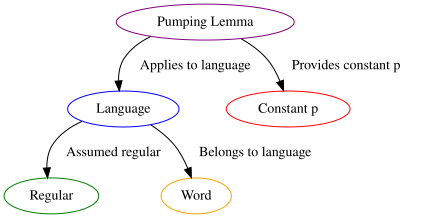

In [16]:
from graphviz import Digraph
from IPython.display import display_svg


def visualize_knowledge_graph(kg: KnowledgeGraph):
    dot = Digraph(comment="Knowledge Graph")
    # Add nodes
    for node in kg.nodes:
        dot.node(str(node.id), node.label, color=node.color)
    # Add edges
    for edge in kg.edges:
        dot.edge(str(edge.source), str(edge.target), label=edge.label, color=edge.color)
    # Render the graph
    dot.render("knowledge_graph.gv", view=False)
    display_svg(dot)

visualize_knowledge_graph(graph)

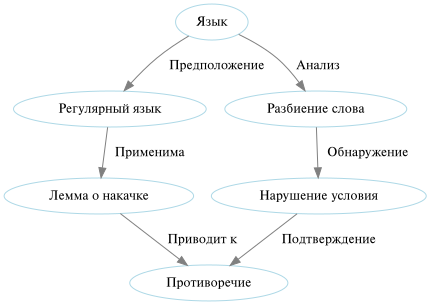

In [19]:
from graphviz import Digraph
from IPython.display import display_svg


def visualize_knowledge_graph(kg: KnowledgeGraph):
    dot = Digraph(comment="Knowledge Graph")
    # Add nodes
    for node in kg.nodes:
        dot.node(str(node.id), node.label, color=node.color)
    # Add edges
    for edge in kg.edges:
        dot.edge(str(edge.source), str(edge.target), label=edge.label, color=edge.color)
    # Render the graph
    dot.render("knowledge_graph.gv", view=False)
    display_svg(dot)

visualize_knowledge_graph(graph)

In [21]:
graph_all = generate_graph(" ".join([x["block_content"] for x in data_t2["parsing_res_list"]]))

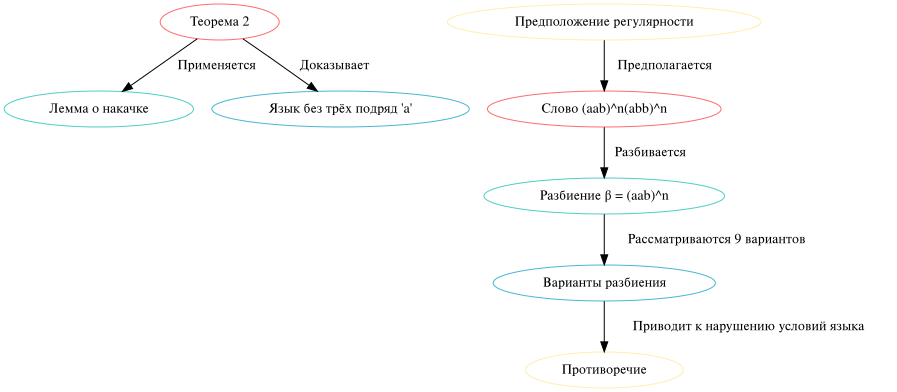

In [22]:
visualize_knowledge_graph(graph_all)